In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
house_prices = pd.read_csv('../datasets/house_prices_cleaned.zip')
house_copy = house_prices.copy()
house_copy.drop(columns= ['title'], axis= 'columns', inplace= True)

C:\Users\HP\AppData\Local\Temp\ipykernel_11704\1389136181.py:1: DtypeWarning: Columns (0: locality) have mixed types. Specify dtype option on import or set low_memory=False.
  house_prices = pd.read_csv('../datasets/house_prices_cleaned.zip')


In [47]:
house_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 68192 entries, 0 to 68191
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          68192 non-null  int64  
 1   description         65974 non-null  str    
 2   amount              67841 non-null  float64
 3   price               63575 non-null  float64
 4   location            68192 non-null  str    
 5   carpet_area         38075 non-null  float64
 6   floor               65577 non-null  str    
 7   transaction         68114 non-null  str    
 8   furnishing          68192 non-null  str    
 9   facing              41392 non-null  str    
 10  overlooking         38657 non-null  str    
 11  society             29372 non-null  str    
 12  bathroom            67721 non-null  float64
 13  balcony             49133 non-null  float64
 14  car_parking         28863 non-null  float64
 15  ownership           43264 non-null  str    
 16  super_area     

In [48]:
house_copy.isna().mean()*100

Unnamed: 0             0.000000
description            3.252581
amount                 0.514723
price                  6.770589
location               0.000000
carpet_area           44.165005
floor                  3.834761
transaction            0.114383
furnishing             0.000000
facing                39.300798
overlooking           43.311532
society               56.927499
bathroom               0.690697
balcony               27.949026
car_parking           57.673921
ownership             36.555608
super_area             6.502229
bedrooms               0.529388
locality              78.579599
total_floors           3.905150
car_parking_status    57.673921
dtype: float64

In [49]:
house_copy['carpet/super'] = house_copy['carpet_area'] / house_copy['super_area']

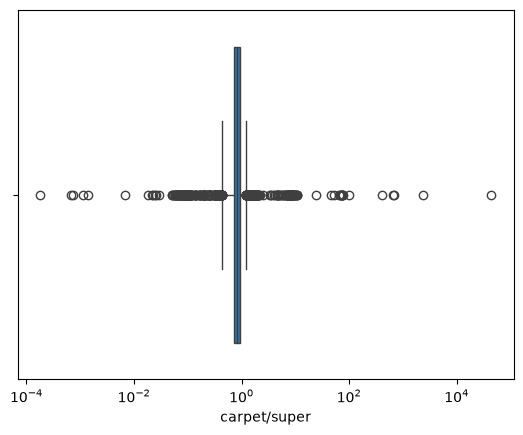

In [50]:
sns.boxplot(data= house_copy, x= 'carpet/super')
plt.xscale('log')

In [51]:
min = house_copy['carpet/super'].quantile(0.25)
max = house_copy['carpet/super'].quantile(0.75)

minimum = min - (max - min) * 1.5

outliers = ((house_copy['carpet/super'] > 1) | (house_copy['carpet/super'] < minimum)).sum()
real = ((house_copy['carpet/super'] <= 1) & (house_copy['carpet/super'] >= minimum)).sum()
print(outliers, real)

2506 31278


(0.0, 300.0)

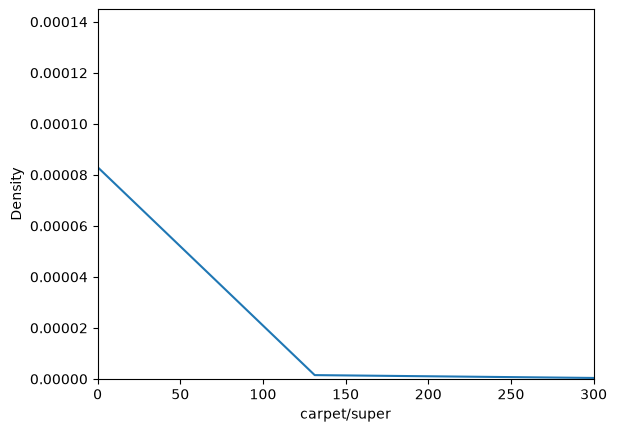

In [52]:
sns.kdeplot(x= house_copy['carpet/super'])
plt.xlim(0, 300)

(0.0, 1.5)

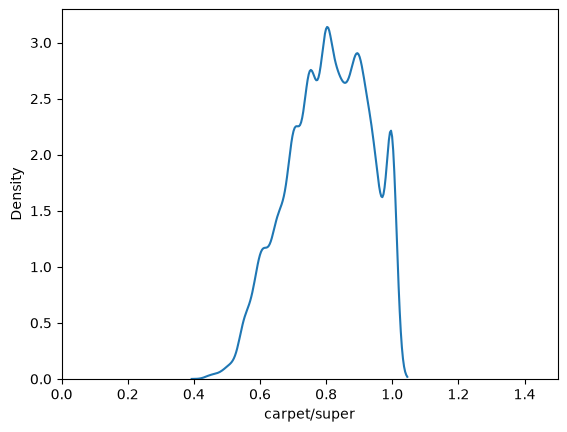

In [53]:
sns.kdeplot(x= house_copy[(house_copy['carpet/super'] <= 1) & (house_copy['carpet/super'] >= minimum)]['carpet/super'])
plt.xlim(0, 1.5)

In [54]:
df = house_copy[(house_copy['carpet/super'] <= 1) & (house_copy['carpet/super'] >= minimum)]

(0.0, 5000.0)

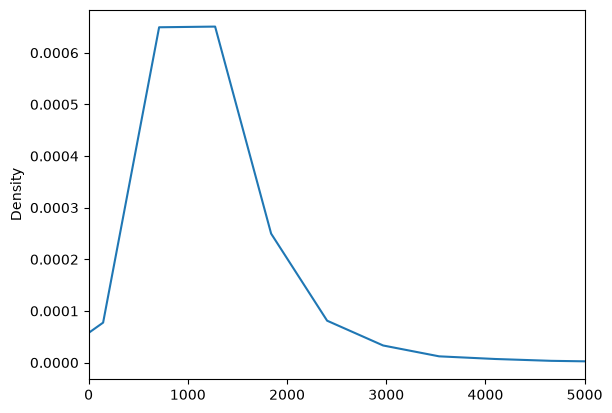

In [55]:
df['carpet_area'].plot(kind= 'density')
plt.xlim(0, 5000)

<Axes: xlabel='carpet_area'>

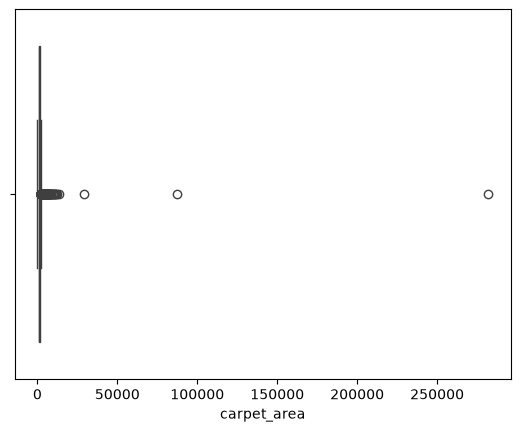

In [56]:
sns.boxplot(x= df['carpet_area'])

In [57]:
df.loc[df['carpet_area'] > 20000,:]

,Unnamed: 0,description,amount,price,location,carpet_area,floor,transaction,furnishing,facing,...,bathroom,balcony,car_parking,ownership,super_area,bedrooms,locality,total_floors,car_parking_status,carpet/super
24222,113787,This ready to move-in 6 BHK flat is available ...,180.0,103.0,lucknow,87120.0,8,Resale,Unfurnished,North - West,...,4.0,2.0,256.0,Freehold,174757.281553,6.0,NaN,10.0,Covered,0.498520
31166,147580,Creatively planned and constructed is a 3 BHK ...,20.0,7.0,agra,282004.0,3,Resale,Unfurnished,NaN,...,2.0,10.0,NaN,NaN,285714.285714,3.0,NaN,6.0,NaN,0.987014
37841,154256,Discover this immaculate > 10 BHK flat for sal...,1000.0,3333.0,ernakulam,29000.0,1,Resale,Furnished,East,...,11.0,11.0,6.0,Freehold,30003.000300,NaN,NaN,3.0,Covered,0.966570


In [58]:
df.drop(index= [24222, 31166], inplace= True)

<Axes: xlabel='carpet_area'>

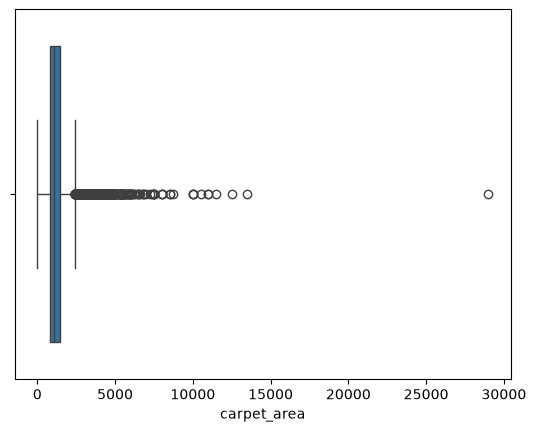

In [59]:
sns.boxplot(x= df['carpet_area'])

In [60]:
df.describe()

,Unnamed: 0,amount,price,carpet_area,bathroom,balcony,car_parking,super_area,bedrooms,total_floors,carpet/super
count,31276.000000,31276.000000,3.127600e+04,31276.000000,31265.000000,29503.000000,17809.000000,31276.000000,31156.000000,30855.000000,31276.000000
mean,122411.963039,120.491095,7.177615e+03,1229.393281,2.508780,2.140969,3.601325,1535.273609,2.639973,9.129282,0.806515
std,60404.912399,894.614952,5.084568e+04,688.173089,0.875646,1.003565,31.307154,847.902724,0.807217,7.410960,0.119962
min,0.000000,1.100000,4.800000e+01,5.000000,1.000000,1.000000,1.000000,5.999945,1.000000,1.000000,0.438669
25%,72693.500000,45.000000,3.902750e+03,811.000000,2.000000,1.000000,1.000000,1049.949032,2.000000,4.000000,0.720000
50%,151194.500000,70.000000,5.180000e+03,1100.000000,2.000000,2.000000,1.000000,1360.000000,3.000000,6.000000,0.809733
75%,170102.250000,122.000000,7.543000e+03,1463.000000,3.000000,3.000000,1.000000,1800.000000,3.000000,13.000000,0.900000
max,187528.000000,140030.000000,6.700000e+06,29000.000000,11.000000,11.000000,999.000000,30003.000300,10.000000,91.000000,1.000000


<Axes: xlabel='super_area'>

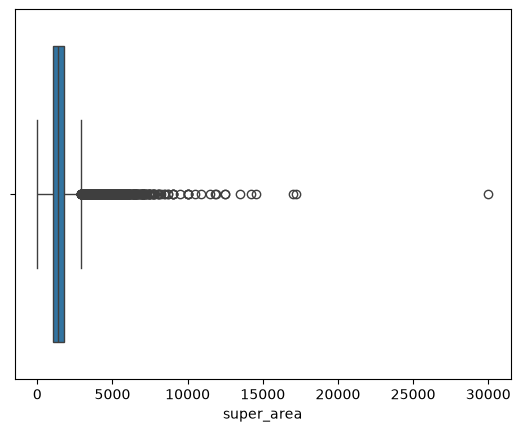

In [61]:
sns.boxplot(x= df['super_area'])

In [62]:
df.groupby('location')['total_floors'].median().sort_values(ascending= False)

location
greater-noida    19.0
noida            19.0
mumbai           18.0
kozhikode        18.0
thane            18.0
                 ... 
shimla            4.0
pondicherry       3.5
madurai           3.0
palakkad          3.0
trichy            3.0
Name: total_floors, Length: 81, dtype: float64

In [63]:
def categorize(s):
    if pd.isna(s): return 
    elif s < 11: return 'low'
    elif s < 31: return 'mid'
    elif s < 61: return 'high'
    else: return 'very high'

df['total_floors_cat'] = df['total_floors'].apply(categorize)

In [64]:
df['total_floors_cat'].value_counts()

total_floors_cat
low          20494
mid           9849
high           495
very high       17
Name: count, dtype: int64

In [65]:
total_floor_groups = df.groupby('total_floors_cat')['amount']
print(f"Median : \n{total_floor_groups.median()}")
print(f"Means : \n{total_floor_groups.mean()}")

Median : 
total_floors_cat
high         249.0
low           62.0
mid           85.6
very high    900.0
Name: amount, dtype: float64
Means : 
total_floors_cat
high         345.562828
low          108.951874
mid          130.976515
very high    971.764706
Name: amount, dtype: float64


In [66]:
df.describe()

,Unnamed: 0,amount,price,carpet_area,bathroom,balcony,car_parking,super_area,bedrooms,total_floors,carpet/super
count,31276.000000,31276.000000,3.127600e+04,31276.000000,31265.000000,29503.000000,17809.000000,31276.000000,31156.000000,30855.000000,31276.000000
mean,122411.963039,120.491095,7.177615e+03,1229.393281,2.508780,2.140969,3.601325,1535.273609,2.639973,9.129282,0.806515
std,60404.912399,894.614952,5.084568e+04,688.173089,0.875646,1.003565,31.307154,847.902724,0.807217,7.410960,0.119962
min,0.000000,1.100000,4.800000e+01,5.000000,1.000000,1.000000,1.000000,5.999945,1.000000,1.000000,0.438669
25%,72693.500000,45.000000,3.902750e+03,811.000000,2.000000,1.000000,1.000000,1049.949032,2.000000,4.000000,0.720000
50%,151194.500000,70.000000,5.180000e+03,1100.000000,2.000000,2.000000,1.000000,1360.000000,3.000000,6.000000,0.809733
75%,170102.250000,122.000000,7.543000e+03,1463.000000,3.000000,3.000000,1.000000,1800.000000,3.000000,13.000000,0.900000
max,187528.000000,140030.000000,6.700000e+06,29000.000000,11.000000,11.000000,999.000000,30003.000300,10.000000,91.000000,1.000000


<Axes: xlabel='carpet_area'>

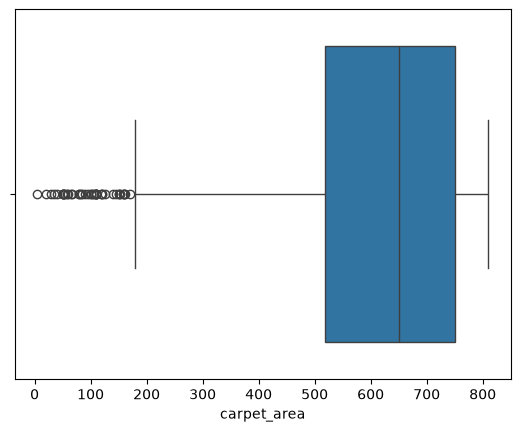

In [67]:
sns.boxplot(x= df[df['carpet_area'] < 811]['carpet_area'])

In [68]:
test = df[df['carpet_area'] < 811]
iqr = test['carpet_area'].quantile(0.75) - test['carpet_area'].quantile(0.25)
min = test['carpet_area'].quantile(0.25) - 1.5 * iqr
test[test['carpet_area'] < 272]

,Unnamed: 0,description,amount,price,location,carpet_area,floor,transaction,furnishing,facing,...,balcony,car_parking,ownership,super_area,bedrooms,locality,total_floors,car_parking_status,carpet/super,total_floors_cat
332,332,Well-tucked in the Hiranandani Solitaire towns...,56.0,14359.0,thane,263.00,25,Resale,Unfurnished,East,...,1.0,NaN,Freehold,389.999304,NaN,Studio Apartment for sale Hiranandani Estate,36.0,NaN,0.674360,high
966,966,This exquisite 1 BHK Flat is offered for sale ...,15.0,4762.0,thane,233.00,Ground,Resale,Unfurnished,NaN,...,NaN,NaN,Co-operative Society,314.993700,1.0,Ambivli,7.0,NaN,0.739697,low
1308,1309,This magnificent 1 BHK Flat is available for s...,25.0,7576.0,navi-mumbai,210.00,2,Resale,Semi-Furnished,NaN,...,NaN,NaN,NaN,329.989440,1.0,CBD Belapur,4.0,NaN,0.636384,low
1317,1318,This attractive 1 BHK apartment can be found f...,30.0,6977.0,navi-mumbai,220.00,4,Resale,Semi-Furnished,NaN,...,1.0,NaN,NaN,429.984234,1.0,Airoli,4.0,NaN,0.511647,low
1738,1739,This flat for resale is just the type of prope...,53.0,16562.0,mumbai,220.00,4,Resale,Unfurnished,East,...,NaN,NaN,Co-operative Society,320.009661,NaN,Bandra gymkhana Mumbai,7.0,NaN,0.687479,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59141,178471,This beautiful 1 BHK Flat is available for sal...,24.0,37500.0,surat,53.00,4,Resale,Unfurnished,NaN,...,1.0,NaN,NaN,64.000000,1.0,NaN,8.0,NaN,0.828125,low
62474,181811,Creatively planned and constructed is a 1 BHK ...,20.0,5806.0,vadodara,161.46,2,Resale,Unfurnished,NaN,...,1.0,NaN,Freehold,344.471237,1.0,NaN,6.0,NaN,0.468718,low
62735,182073,Carefully laid out in the prime location of Ak...,17.0,5667.0,vadodara,250.00,2,Resale,Unfurnished,East,...,2.0,NaN,Freehold,299.982354,1.0,NaN,4.0,NaN,0.833382,low
64650,183988,One can find this stunning 1 BHK flat for sale...,16.0,3628.0,vijayawada,229.00,3,Resale,Semi-Furnished,NaN,...,NaN,NaN,NaN,441.014333,1.0,NaN,5.0,NaN,0.519258,low


<Axes: xlabel='bedrooms', ylabel='bathroom'>

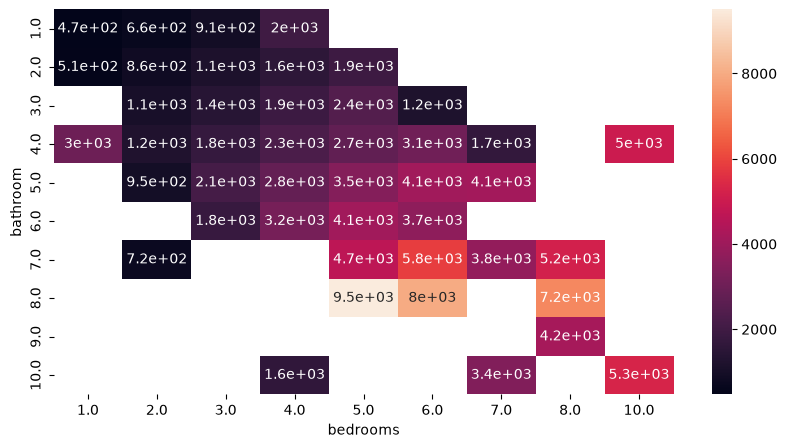

In [69]:
table = df.pivot_table(values= 'carpet_area', columns= 'bedrooms', index= 'bathroom', aggfunc= 'mean')
fig = plt.figure(figsize= (10, 5))
ax = fig.add_subplot(111)
sns.heatmap(table, annot= True, ax= ax)

<Axes: xlabel='bedrooms', ylabel='bathroom'>

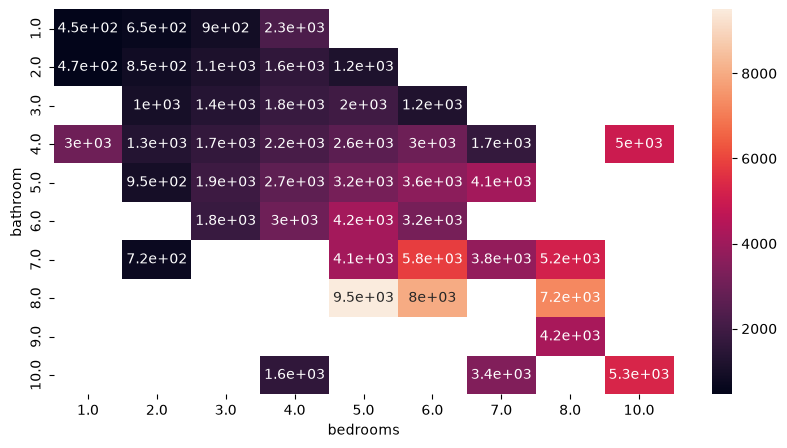

In [70]:
table = df.pivot_table(values= 'carpet_area', columns= 'bedrooms', index= 'bathroom', aggfunc= 'median')
fig = plt.figure(figsize= (10, 5))
ax2 = fig.add_subplot(111)
sns.heatmap(table, annot= True, ax= ax2)

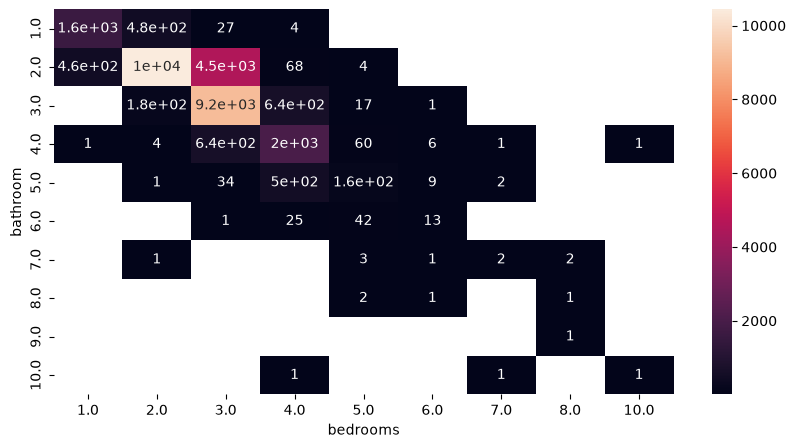

In [71]:
df['count'] = 1
table = df.pivot_table(values= 'count', columns= 'bedrooms', index= 'bathroom', aggfunc= 'sum')
fig = plt.figure(figsize= (10, 5))
ax1 = fig.add_subplot(111)
sns.heatmap(table, annot= True, ax= ax1)
df.drop(columns='count', axis= 'columns', inplace= True)

In [72]:
len(df)

31276

In [73]:
df = df[(df['bedrooms'] < 7) & (df['bathroom'] < 9) & ((df['bedrooms'] + 2) >= df['bathroom']) | (df['bedrooms'].isna() | df['bathroom'].isna())]
df

,Unnamed: 0,description,amount,price,location,carpet_area,floor,transaction,furnishing,facing,...,balcony,car_parking,ownership,super_area,bedrooms,locality,total_floors,car_parking_status,carpet/super,total_floors_cat
0,0,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42.0,6000.0,thane,500.0,10,Resale,Unfurnished,NaN,...,2.0,NaN,NaN,700.000000,1.0,Bhiwandi,11.0,NaN,0.714286,mid
1,1,One can find this stunning 2 BHK flat for sale...,98.0,13799.0,thane,473.0,3,Resale,Semi-Furnished,East,...,NaN,1.0,Freehold,710.196391,2.0,Pokhran Road,22.0,Open,0.666013,mid
2,2,Up for immediate sale is a 2 BHK apartment in ...,140.0,17500.0,thane,779.0,10,Resale,Unfurnished,East,...,NaN,1.0,Freehold,800.000000,2.0,Kolshet Road,29.0,Covered,0.973750,mid
4,4,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",160.0,18824.0,thane,635.0,20,Resale,Unfurnished,West,...,NaN,1.0,Co-operative Society,849.978751,2.0,Pokhran Road,42.0,Covered,0.747077,high
6,6,This magnificent 1 BHK Flat is available for s...,16.5,2538.0,thane,550.0,4,Resale,Unfurnished,NaN,...,NaN,NaN,NaN,650.118203,1.0,Mumbra,5.0,NaN,0.846000,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68183,187522,Up for immediate sale is a 3 BHK apartment in ...,80.0,4040.0,zirakpur,1200.0,3,Resale,Semi-Furnished,East,...,3.0,NaN,Freehold,1980.198020,3.0,NaN,3.0,NaN,0.606000,low
68184,187523,This magnificent 5 BHK Flat is available for s...,119.0,4547.0,zirakpur,1705.0,5,Resale,Semi-Furnished,North - East,...,3.0,1.0,Freehold,2617.110183,5.0,NaN,10.0,Covered,0.651482,low
68185,187524,One can find this stunning 3 BHK flat for sale...,69.6,5135.0,zirakpur,895.0,5,Resale,Semi-Furnished,North - East,...,2.0,1.0,Freehold,1355.404090,3.0,NaN,8.0,Covered,0.660320,low
68186,187525,Have a look at this immaculate 3 BHK flat for ...,44.9,3904.0,zirakpur,1050.0,1,New Property,Unfurnished,North - East,...,2.0,NaN,Freehold,1150.102459,3.0,NaN,3.0,NaN,0.912962,low


In [74]:
df['floor'].value_counts()
df['balcony'].value_counts()

balcony
2.0     11714
1.0      8560
3.0      6414
4.0      2261
5.0       451
6.0        62
8.0         7
7.0         6
10.0        5
11.0        4
9.0         1
Name: count, dtype: int64

In [75]:
df= df[((df['floor'].isin(['Upper Basement', 'Lower Basement']) & (df['balcony'] > 0)) == False)  | df['balcony'].isna()]
df

,Unnamed: 0,description,amount,price,location,carpet_area,floor,transaction,furnishing,facing,...,balcony,car_parking,ownership,super_area,bedrooms,locality,total_floors,car_parking_status,carpet/super,total_floors_cat
0,0,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42.0,6000.0,thane,500.0,10,Resale,Unfurnished,NaN,...,2.0,NaN,NaN,700.000000,1.0,Bhiwandi,11.0,NaN,0.714286,mid
1,1,One can find this stunning 2 BHK flat for sale...,98.0,13799.0,thane,473.0,3,Resale,Semi-Furnished,East,...,NaN,1.0,Freehold,710.196391,2.0,Pokhran Road,22.0,Open,0.666013,mid
2,2,Up for immediate sale is a 2 BHK apartment in ...,140.0,17500.0,thane,779.0,10,Resale,Unfurnished,East,...,NaN,1.0,Freehold,800.000000,2.0,Kolshet Road,29.0,Covered,0.973750,mid
4,4,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",160.0,18824.0,thane,635.0,20,Resale,Unfurnished,West,...,NaN,1.0,Co-operative Society,849.978751,2.0,Pokhran Road,42.0,Covered,0.747077,high
6,6,This magnificent 1 BHK Flat is available for s...,16.5,2538.0,thane,550.0,4,Resale,Unfurnished,NaN,...,NaN,NaN,NaN,650.118203,1.0,Mumbra,5.0,NaN,0.846000,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68183,187522,Up for immediate sale is a 3 BHK apartment in ...,80.0,4040.0,zirakpur,1200.0,3,Resale,Semi-Furnished,East,...,3.0,NaN,Freehold,1980.198020,3.0,NaN,3.0,NaN,0.606000,low
68184,187523,This magnificent 5 BHK Flat is available for s...,119.0,4547.0,zirakpur,1705.0,5,Resale,Semi-Furnished,North - East,...,3.0,1.0,Freehold,2617.110183,5.0,NaN,10.0,Covered,0.651482,low
68185,187524,One can find this stunning 3 BHK flat for sale...,69.6,5135.0,zirakpur,895.0,5,Resale,Semi-Furnished,North - East,...,2.0,1.0,Freehold,1355.404090,3.0,NaN,8.0,Covered,0.660320,low
68186,187525,Have a look at this immaculate 3 BHK flat for ...,44.9,3904.0,zirakpur,1050.0,1,New Property,Unfurnished,North - East,...,2.0,NaN,Freehold,1150.102459,3.0,NaN,3.0,NaN,0.912962,low


In [76]:
df['floor'].unique()

<StringArray>
[            '10',              '3',             '20',              '4',
              '6',             '18',             '15',              '2',
             '27',              '8',              '9',             '16',
             '14',             '12',              '1',              '5',
              '7',             '21',         'Ground',             '13',
             '19',             '11',             '17',             '28',
             '30',             '23',             '25',             '26',
             '24',              nan,             '29',             '22',
             '32',             '33',             '35',             '40',
 'Upper Basement',             '38',             '34',             '31',
             '37',             '75',             '39',             '44',
             '36',             '59',             '45',             '51',
 'Lower Basement',             '42']
Length: 50, dtype: str

In [77]:
floor_group = df.groupby('floor')['amount'].median()
floor_group


floor
1                   65.00
10                  95.10
11                  89.00
12                  99.00
13                  90.00
14                  95.50
15                 107.00
16                 125.00
17                 135.00
18                 135.00
19                 103.00
2                   62.40
20                 149.00
21                 186.00
22                 145.00
23                 144.00
24                 165.00
25                 235.00
26                 140.00
27                 190.00
28                 200.00
29                 295.00
3                   62.00
30                 236.00
31                 295.00
32                 395.00
33                 170.00
34                 650.00
35                 420.00
36                 725.00
37                 260.00
38                 477.50
39                 472.50
4                   66.00
40                 735.00
42                 750.00
44                1320.00
45                2200.00
5     

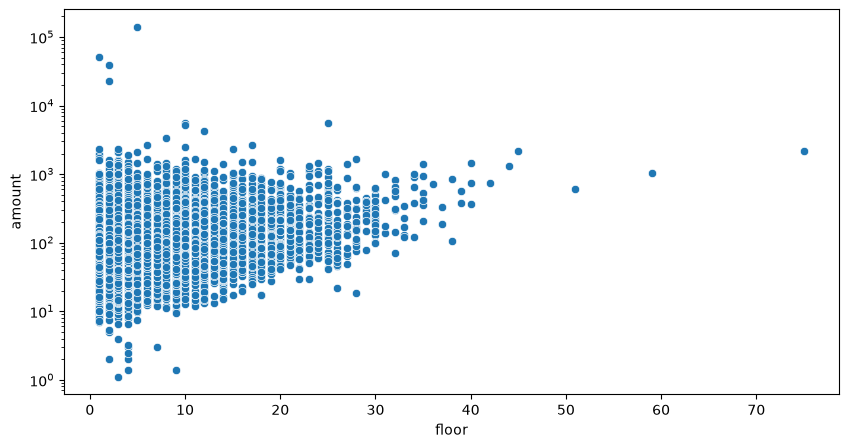

In [78]:
fig = plt.figure(figsize= (10, 5))
ax3= fig.add_subplot()
floor_group_ = df[df['floor'].isin(['Ground', 'Upper Basement', 'Lower Basement', np.nan]) == False]
floor_group_['floor'] = floor_group_['floor'].astype('int16')
sns.scatterplot(x= floor_group_['floor'], y= floor_group_['amount'], ax= ax3)
plt.yscale('log')

In [79]:
floor_group_.corr(numeric_only= True)[['floor', 'amount']]

,floor,amount
Unnamed: 0,-0.164575,-0.033819
amount,0.032330,1.000000
price,0.017762,0.954977
carpet_area,0.092160,0.099806
floor,1.000000,0.032330
bathroom,0.147957,0.086216
balcony,0.186120,0.046317
car_parking,-0.001458,-0.003481
super_area,0.143988,0.108716
bedrooms,0.086091,0.076252


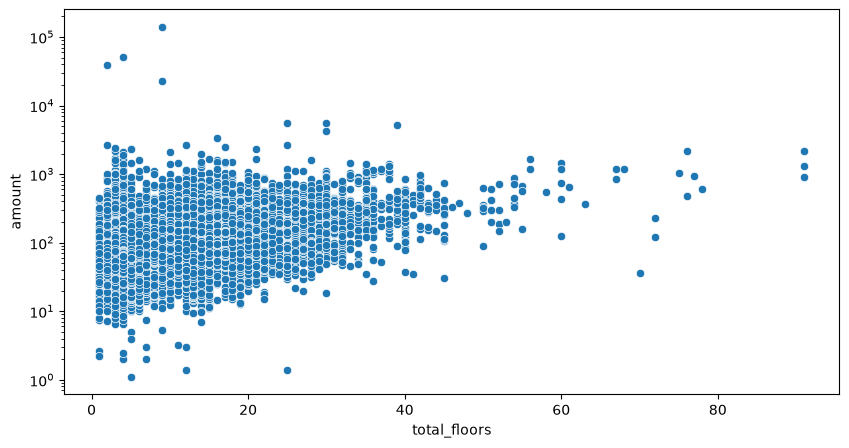

In [80]:
fig = plt.figure(figsize= (10, 5))
ax4= fig.add_subplot()
sns.scatterplot(x= df['total_floors'], y= df['amount'], ax= ax4)
plt.yscale('log')

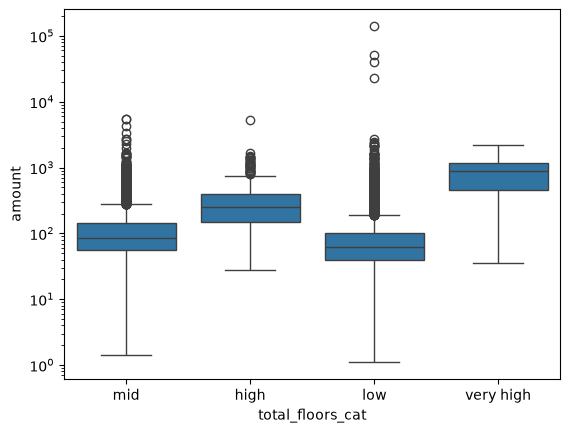

In [81]:
sns.boxplot(x= df['total_floors_cat'], y= df['amount'])
plt.yscale('log')

In [82]:
df['floor_cat'] = np.where(df['floor'].isin(['Ground', 'Upper Basement', 'Lower Basement']), df['floor'], 
                           pd.to_numeric(df['floor'], errors= 'coerce').apply(categorize))

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'low'),
  Text(1, 0, 'mid'),
  Text(2, 0, 'Ground'),
  Text(3, 0, 'high'),
  Text(4, 0, 'Upper Basement'),
  Text(5, 0, 'very high'),
  Text(6, 0, 'Lower Basement')])

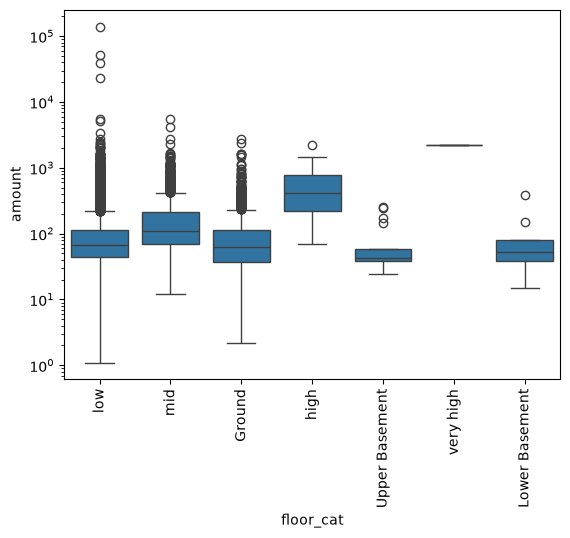

In [83]:
sns.boxplot(x= df['floor_cat'], y= df['amount'])
plt.yscale('log')
plt.xticks(rotation= 90)

In [84]:
df.isna().mean()*100

Unnamed: 0             0.000000
description            0.823575
amount                 0.000000
price                  0.000000
location               0.000000
carpet_area            0.000000
floor                  1.338309
transaction            0.009651
furnishing             0.000000
facing                16.239866
overlooking           20.804916
society               50.479346
bathroom               0.035388
balcony                5.700682
car_parking           43.038219
ownership             14.084416
super_area             0.000000
bedrooms               0.386051
locality              77.940420
total_floors           1.354395
car_parking_status    43.038219
carpet/super           0.000000
total_floors_cat       1.354395
floor_cat              1.338309
dtype: float64

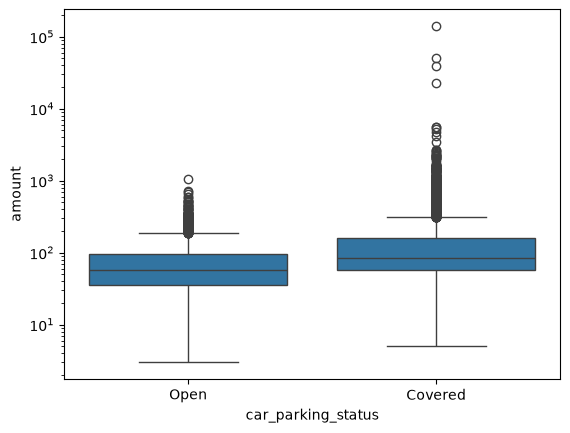

In [85]:
sns.boxplot(x= df['car_parking_status'], y= df['amount'])
plt.yscale('log')

In [94]:
df.isna().mean() * 100

amount                 0.000000
price                  0.000000
location               0.000000
carpet_area            0.000000
floor                  1.338309
transaction            0.009651
furnishing             0.000000
overlooking           20.804916
society               50.479346
bathroom               0.035388
balcony                5.700682
car_parking           43.038219
ownership             14.084416
super_area             0.000000
bedrooms               0.386051
total_floors           1.354395
car_parking_status    43.038219
total_floors_cat       1.338309
floor_cat              1.338309
dtype: float64

In [ ]:
df.loc[df['total_floors_cat'].isna(), 'total_floors_cat'] = df['floor_cat']

In [ ]:
df.drop(columns= ['Unnamed: 0', 'description', 'facing', 'locality', 'carpet/super', ], axis= 'columns', inplace= True)